# Letterform Representation Demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ipavlopoulos/diachronic-greek-letterforms/blob/main/representation_demo.ipynb)

This notebook loads the released CNN checkpoint and extracts transparent 512-dimensional letterform representations from Greek letter cliplet images. It is meant as a small, inspectable companion to the larger training and clustering notebooks.

GitHub's notebook view is static. To run the cells online, open this notebook in Google Colab using the badge above.

## 1. Load the tools

The first cell prepares the environment. When the notebook is opened in Colab, it clones the repository automatically so that `source.py`, the model checkpoint, and the sample cliplets are available. It also suppresses low-level library startup messages so the saved notebook keeps the useful outputs visible.

In [1]:
import contextlib
import io
import os
import subprocess
import sys
import warnings
from pathlib import Path

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/ipavlopoulos/diachronic-greek-letterforms.git"
REPO_DIR = Path("/content/diachronic-greek-letterforms")

if IN_COLAB and not Path("source.py").exists():
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    import numpy as np
    import pandas as pd
    import torch
    from IPython.display import display
    from PIL import Image
    from sklearn.metrics.pairwise import cosine_similarity

    from source import LETTER_LABELS, extract_letterform_representations, load_letterform_model

print(f"Ready. Running in {'Colab' if IN_COLAB else 'local Jupyter'} from {Path.cwd()}")

Ready. Running in local Jupyter from /Users/iopa3492/vs/optical-greek-letters/source


## 2. Select example cliplets

The demo uses a small sample from PaLit-Char so it runs quickly. Each input should be a cropped cliplet containing one Greek letterform, similar to the images in `data/palitchar/cliplets`.

In [2]:
checkpoint = "best_cnn_letter_model.pth"
cliplet_dir = Path("data/palitchar/cliplets")
image_paths = sorted(cliplet_dir.glob("*.jpg"))[:20] + sorted(cliplet_dir.glob("*.png"))[:20]
selected_path = image_paths[0]

len(image_paths), selected_path

(40, PosixPath('data/palitchar/cliplets/Alpha_10352_001.jpg'))

## 3. Preview the selected image

This is the first image passed to the encoder. The model expects a single isolated letter crop; it will resize the crop to `64x64` grayscale internally.

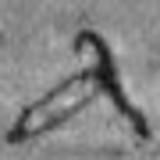

In [3]:
image = Image.open(selected_path).convert("L")
display(image.resize((160, 160)))

## 4. Extract representations

The checkpoint produces class logits and a 512-dimensional representation from the penultimate CNN layer. The helper returns L2-normalized embeddings by default, making cosine similarity directly usable.

Shape note: one image produces one representation vector of shape `1 x 512`. In this demo we encode 40 images, so the embeddings array has shape `40 x 512`.

In [4]:
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    model = load_letterform_model(checkpoint, device="cpu")
    embeddings, logits = extract_letterform_representations(
        model,
        image_paths,
        device="cpu",
        return_logits=True,
    )

probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()
predicted = probabilities.argmax(axis=1)

print(f"Each image has one 512-dimensional representation. Encoded {len(image_paths)} images.")
print(f"Embeddings array shape: {embeddings.shape} = {len(image_paths)} images x 512 dimensions")
print(f"Logits array shape: {logits.shape} = {len(image_paths)} images x {len(LETTER_LABELS)} classes")

Each image has one 512-dimensional representation. Encoded 40 images.
Embeddings array shape: (40, 512) = 40 images x 512 dimensions
Logits array shape: (40, 24) = 40 images x 24 classes


## 5. Inspect predictions and embedding norms

The table below keeps only human-readable metadata plus the norm of each representation. Since the embeddings are normalized, the norm should be approximately `1.0`.

In [5]:
rows = []
for path, pred_idx, probs, embedding in zip(image_paths, predicted, probabilities, embeddings):
    rows.append({
        "filename": str(path),
        "predicted_label": LETTER_LABELS[int(pred_idx)],
        "confidence": float(probs[int(pred_idx)]),
        "embedding_norm": float(np.linalg.norm(embedding)),
    })

summary = pd.DataFrame(rows)
summary.head()

,filename,predicted_label,confidence,embedding_norm
0,data/palitchar/cliplets/Alpha_10352_001.jpg,Lambda,0.475266,1.0
1,data/palitchar/cliplets/Alpha_113270_002.jpg,Alpha,0.528997,1.0
2,data/palitchar/cliplets/Alpha_16545_005.jpg,Lambda,0.615408,1.0
3,data/palitchar/cliplets/Alpha_20196_006.jpg,Alpha,0.854845,1.0
4,data/palitchar/cliplets/Alpha_22213_010.jpg,Alpha,0.541097,1.0


## 6. Find nearest neighbors

Nearest neighbors are computed by cosine similarity in the learned representation space. This gives a quick transparency check: visually similar letterforms should tend to sit near one another.

In [6]:
query_index = 0
similarity = cosine_similarity(embeddings[[query_index]], embeddings)[0]
nearest = np.argsort(-similarity)[:6]

pd.DataFrame({
    "rank": range(1, len(nearest) + 1),
    "filename": [str(image_paths[i]) for i in nearest],
    "predicted_label": [LETTER_LABELS[int(predicted[i])] for i in nearest],
    "cosine_similarity": similarity[nearest],
})

,rank,filename,predicted_label,cosine_similarity
0,1,data/palitchar/cliplets/Alpha_10352_001.jpg,Lambda,1.000000
1,2,data/palitchar/cliplets/Alpha_64413_015.png,Alpha,0.795652
2,3,data/palitchar/cliplets/Alpha_16545_005.jpg,Lambda,0.776454
3,4,data/palitchar/cliplets/Alpha_62075_014.png,Lambda,0.743026
4,5,data/palitchar/cliplets/Alpha_59697_013.jpg,Alpha,0.732367
5,6,data/palitchar/cliplets/Alpha_220465_009.png,Alpha,0.731942


## 7. Export representations

The export keeps the readable columns first, followed by `embedding_000` through `embedding_511`. This CSV can be used for clustering, nearest-neighbor search, or downstream paleographic analysis.

Shape note: the CSV has 516 columns because it stores 4 metadata columns (`filename`, `predicted_label`, `confidence`, `embedding_norm`) plus the 512 representation dimensions. For 40 images, the CSV shape is therefore `40 x 516`.

In [7]:
export = summary.copy()
for dim in range(embeddings.shape[1]):
    export[f"embedding_{dim:03d}"] = embeddings[:, dim]

export.to_csv("representation_demo_output.csv", index=False)
print(f"CSV shape: {export.shape} = {len(export)} images x 516 columns")
print("516 columns = 4 metadata columns + 512 representation dimensions")
export.shape

CSV shape: (40, 516) = 40 images x 516 columns
516 columns = 4 metadata columns + 512 representation dimensions


(40, 516)

## 8. Try your own image

Use this cell in a live notebook session. In Colab it opens Colab's file picker; in local Jupyter it shows an upload widget.

Upload a cropped image of a single Greek letterform, ideally similar to the provided cliplets: one character, grayscale or RGB, minimal surrounding text, and enough margin that the strokes are not cut off. Full manuscript pages should be cropped to one letter first; this model is a letterform encoder, not a page-layout or segmentation model.

In [8]:
def encode_one_image(upload_path):
    upload_path = Path(upload_path)
    display(Image.open(upload_path).convert("L").resize((160, 160)))
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        uploaded_embedding, uploaded_logits = extract_letterform_representations(
            model,
            [upload_path],
            device="cpu",
            return_logits=True,
        )

    uploaded_probs = torch.softmax(torch.tensor(uploaded_logits), dim=1).numpy()[0]
    uploaded_pred = int(uploaded_probs.argmax())
    result = pd.DataFrame([{
        "predicted_label": LETTER_LABELS[uploaded_pred],
        "confidence": float(uploaded_probs[uploaded_pred]),
        "embedding_shape": str(uploaded_embedding.shape),
        "embedding_norm": float(np.linalg.norm(uploaded_embedding[0])),
    }])
    display(result)
    return uploaded_embedding, uploaded_logits

if IN_COLAB:
    from google.colab import files  # type: ignore

    print("Choose a cropped single-letter image file, for example a PNG or JPG cliplet.")
    uploaded = files.upload()
    if uploaded:
        uploaded_name = next(iter(uploaded.keys()))
        uploaded_embedding, uploaded_logits = encode_one_image(uploaded_name)
else:
    try:
        import ipywidgets as widgets

        uploader = widgets.FileUpload(
            accept="image/*",
            multiple=False,
            description="Upload image",
        )
        display(uploader)

        def encode_uploaded_image(change):
            if not uploader.value:
                return

            if isinstance(uploader.value, dict):
                uploaded_file = next(iter(uploader.value.values()))
            else:
                uploaded_file = uploader.value[0]

            upload_path = Path("uploaded_letterform.png")
            upload_path.write_bytes(uploaded_file["content"])
            encode_one_image(upload_path)

        uploader.observe(encode_uploaded_image, names="value")
    except ImportError:
        print("ipywidgets is not installed. Save a cropped single-letter image in this folder and run:")
        print("encode_one_image('your_image.png')")

FileUpload(value=(), accept='image/*', description='Upload image')